In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/akshaj12sharma/nova-task1-data/Metadata.pdf
/kaggle/input/datasets/akshaj12sharma/nova-task1-data/Task 1.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('/kaggle/input/datasets/akshaj12sharma/nova-task1-data/Task 1.csv')
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606.0,301.0,2.0,79.0,6.543777e+18,GALAXY,0.634794,5812.0,56354,171.0
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518.0,301.0,NaN,119.0,1.176014e+19,GALAXY,0.779136,NaN,58158,427.0
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606.0,301.0,NaN,120.0,5.152200e+18,GALAXY,0.644195,NaN,55592,299.0
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192.0,301.0,3.0,214.0,1.030107e+19,GALAXY,0.932346,9149.0,58039,775.0
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102.0,301.0,3.0,137.0,6.891865e+18,GALAXY,0.116123,6121.0,56187,842.0


In [3]:
print("Shape of dataset (R,C):", df.shape)
print()
print("Column data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Number of duplicate rows:", df.duplicated().sum())

Shape of dataset (R,C): (100000, 18)

Column data types:
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID         float64
rerun_ID       float64
cam_col        float64
field_ID       float64
spec_obj_ID    float64
class           object
redshift       float64
plate          float64
MJD              int64
fiber_ID       float64
dtype: object

Missing values per column:
obj_ID             0
alpha           2013
delta           9250
u                 35
g                215
r               1730
i                126
z                888
run_ID             1
rerun_ID           3
cam_col        25474
field_ID           8
spec_obj_ID        2
class              4
redshift          16
plate          12756
MJD                0
fiber_ID           5
dtype: int64

Number of duplicate rows: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        97987 non-null   float64
 2   delta        90750 non-null   float64
 3   u            99965 non-null   float64
 4   g            99785 non-null   float64
 5   r            98270 non-null   float64
 6   i            99874 non-null   float64
 7   z            99112 non-null   float64
 8   run_ID       99999 non-null   float64
 9   rerun_ID     99997 non-null   float64
 10  cam_col      74526 non-null   float64
 11  field_ID     99992 non-null   float64
 12  spec_obj_ID  99998 non-null   float64
 13  class        99996 non-null   object 
 14  redshift     99984 non-null   float64
 15  plate        87244 non-null   float64
 16  MJD          100000 non-null  int64  
 17  fiber_ID     99995 non-null   float64
dtypes: float64(16), int64(1),

In [5]:
print(df['class'].value_counts())
print()
print(df['class'].value_counts(normalize=True) * 100)

class
GALAXY    59442
STAR      21593
QSO       18961
Name: count, dtype: int64

class
GALAXY    59.444378
STAR      21.593864
QSO       18.961758
Name: proportion, dtype: float64


Galaxies make up nearly 60% of all observations, while quasars are the smallest group at under 19%.

/tmp/ipykernel_147/3382895275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, order=df['class'].value_counts().index, palette='viridis')


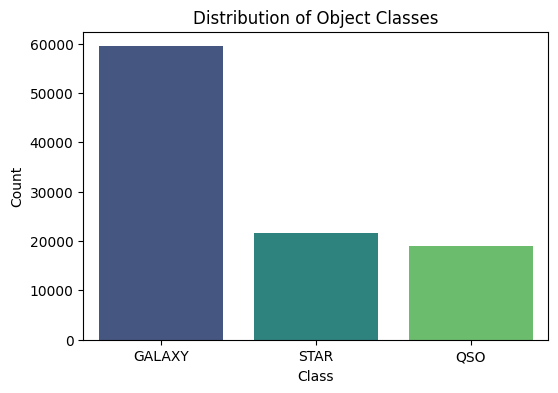

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, order=df['class'].value_counts().index, palette='viridis')
plt.title('Distribution of Object Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

data=df in sns.countplot(x='class', data=df, ...)
This tells seaborn which DataFrame to pull the column from.

In [7]:
df[['u', 'g', 'r', 'i', 'z', 'redshift']].describe()

,u,g,r,i,z,redshift
count,99965.000000,99785.000000,98270.000000,99874.000000,99112.000000,99984.000000
mean,21.980389,20.531585,19.645324,19.085179,18.668293,0.576674
std,31.774821,31.784318,1.855572,1.757937,31.869522,0.730737
min,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,-0.009971
25%,20.352300,18.966220,18.133965,17.732608,17.461787,0.054503
50%,22.179130,21.099690,20.125750,19.405385,19.004650,0.424173
75%,23.687400,22.123740,21.044522,20.396653,19.921083,0.704154
max,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


It gives the central tendency (mean, median) and spread (std, min/max, quartiles) of each magnitude band and redshift. 

Counts — u:99,965, g:99,785, r:98,270, i:99,874, z:99,112, redshift:99,984 — these match non-null values we found earlier for each column.
Problem - min = -9999 in u, g, and z. Real photometric magnitudes are never negative thousand.

In [8]:
for col in ['u', 'g', 'r', 'i', 'z']:
    print(col, ':', (df[col] == -9999).sum(), 'values equal to -9999')

u : 1 values equal to -9999
g : 1 values equal to -9999
r : 0 values equal to -9999
i : 0 values equal to -9999
z : 1 values equal to -9999


1 row each in u, g, and z, a single extreme value like -9999 is enough to massively distort the mean and especially the standard deviation

In [9]:
df[['u', 'g', 'z']] = df[['u', 'g', 'z']].replace(-9999, np.nan)
df[['u', 'g', 'r', 'i', 'z', 'redshift']].describe()

,u,g,r,i,z,redshift
count,99964.000000,99784.000000,98270.000000,99874.000000,99111.000000,99984.000000
mean,22.080635,20.631997,19.645324,19.085179,18.769368,0.576674
std,2.251032,2.037042,1.855572,1.757937,1.765780,0.730737
min,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971
25%,20.352353,18.966220,18.133965,17.732608,17.461825,0.054503
50%,22.179135,21.099715,20.125750,19.405385,19.004660,0.424173
75%,23.687440,22.123745,21.044522,20.396653,19.921085,0.704154
max,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


Count for u is now 99,964 (one less than before, since that one -9999 became NaN)

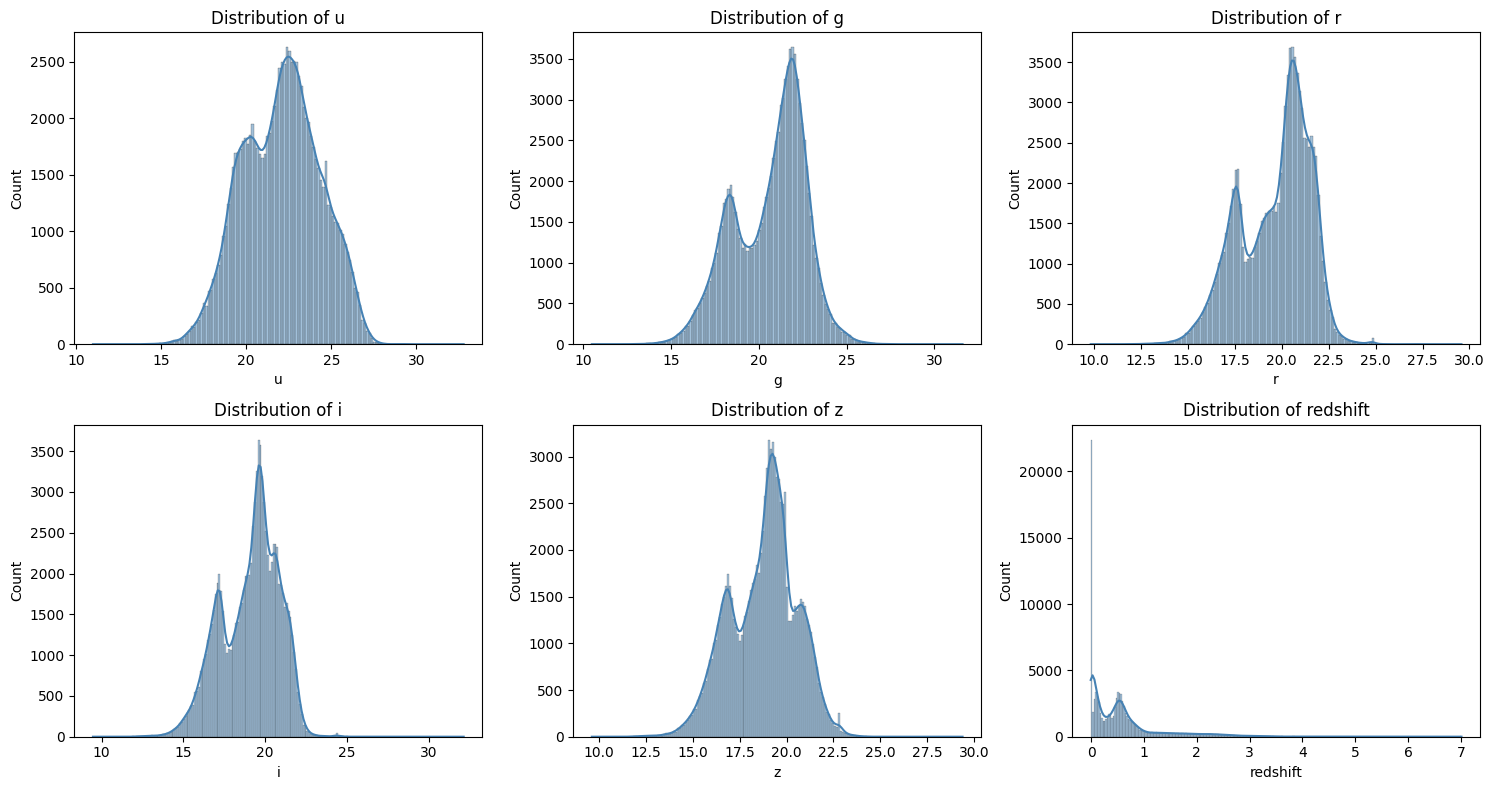

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['u', 'g', 'r', 'i', 'z', 'redshift']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

1. plt.subplots(2, 3, figsize=(15, 8)) — creates a grid of 2 rows × 3 columns = 6 subplot slots in one figure, sized 15×8 inches. 
2. Returns fig (the whole figure) and axes (an array of the 6 individual subplot areas).
3. axes.flatten() — converts the 2D grid of axes (2 rows × 3 cols) into a simple 1D list, so we can loop through them one at a time alongside cols.
4. zip(axes.flatten(), cols) — pairs up each subplot slot with a column name, one-to-one.
sns.histplot(df[col], kde=True, ax=ax, color='steelblue') — draws a histogram (bars showing how many values fall into each range) for that column, with kde=True overlaying a smooth curve (Kernel Density Estimate) showing the distribution's shape. ax=ax tells seaborn to draw into that specific subplot slot instead of creating a new figure. Alternative: plt.hist(df[col]) gives a plain histogram without the smooth curve or seaborn's styling.
ax.set_title(...) — labels each subplot individually.
plt.tight_layout() — automatically adjusts spacing so subplot titles/labels don't overlap each other.
plt.show() — renders everything.

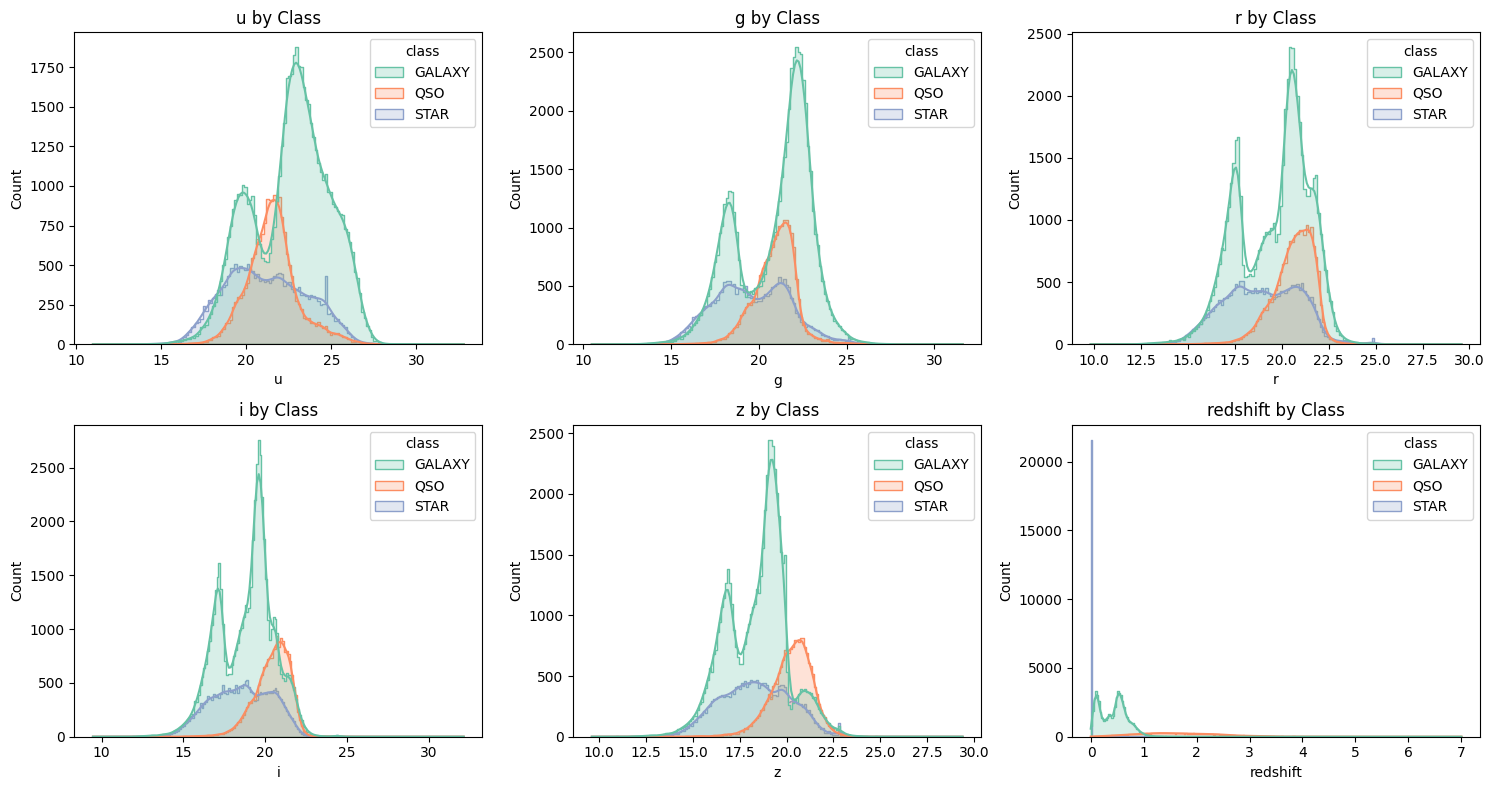

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['u', 'g', 'r', 'i', 'z', 'redshift']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(data=df, x=col, hue='class', kde=True, ax=ax, palette='Set2', element='step')
    ax.set_title(f'{col} by Class')

plt.tight_layout()
plt.show()

element='step' — draws the histogram as outlined step lines instead of solid filled bars, which makes overlapping distributions easier to see through each other (rather than blocks fully covering one another).

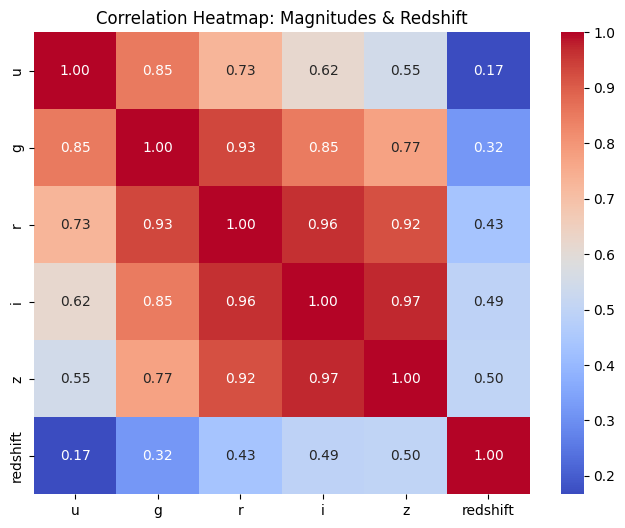

In [12]:
plt.figure(figsize=(8,6))
corr = df[['u', 'g', 'r', 'i', 'z', 'redshift']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Magnitudes & Redshift')
plt.show()

In [15]:
df['obs_date'] = pd.Timestamp('1858-11-17') + pd.to_timedelta(df['MJD'], unit='D')
df['obs_year'] = df['obs_date'].dt.year
df['obs_month'] = df['obs_date'].dt.month

df[['MJD', 'obs_date', 'obs_year', 'obs_month']].head()

,MJD,obs_date,obs_year,obs_month
0,56354,2013-03-03,2013,3
1,58158,2018-02-09,2018,2
2,55592,2011-01-31,2011,1
3,58039,2017-10-13,2017,10
4,56187,2012-09-17,2012,9


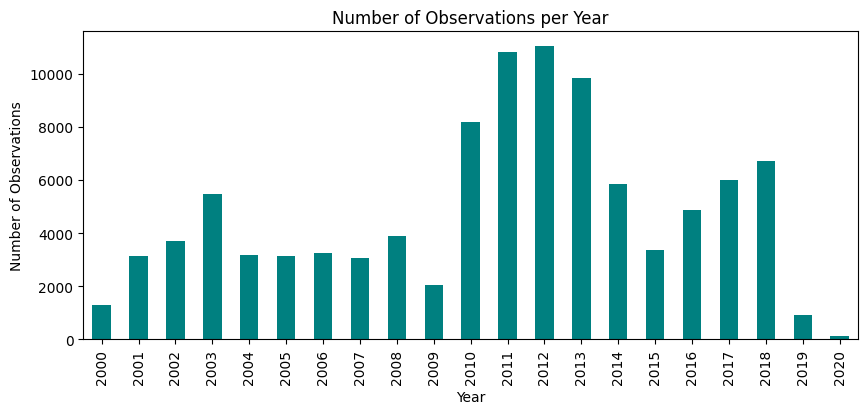

In [16]:
plt.figure(figsize=(10,4))
df['obs_year'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Observations')
plt.show()

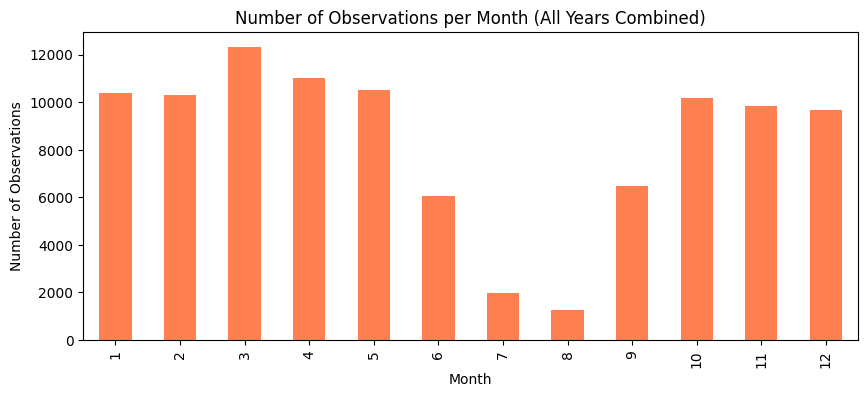

In [17]:
plt.figure(figsize=(10,4))
df['obs_month'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Number of Observations per Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Number of Observations')
plt.show()

## Observations and Conclusion

**Dataset Overview:** The dataset contains 100,000 astronomical observations from the Sloan Digital Sky Survey (SDSS) with 18 features, classifying objects as GALAXY, STAR, or QSO (quasar).

**Class Distribution:** The dataset is imbalanced — GALAXY makes up ~59.4% of records, STAR ~21.6%, and QSO ~19.0%. This likely reflects real observational astronomy, where galaxies are more commonly catalogued than quasars, but it is worth accounting for in any downstream modeling to avoid bias toward the majority class.

**Data Quality Issue Found and Fixed:** The `u`, `g`, and `z` magnitude columns each contained a single sentinel value of -9999, used as a placeholder for a failed/invalid measurement. Left unaddressed, this single value per column inflated the standard deviation roughly 15x (e.g., `u`'s std dropped from ~31.8 to ~2.3 after correction) and distorted the reported minimum. These were replaced with NaN before further analysis.

**Magnitude and Redshift Distributions:** All five photometric magnitude bands (u, g, r, i, z) showed bimodal distributions. Splitting by class revealed the cause: STAR objects cluster at systematically brighter magnitudes than GALAXY and QSO, which overlap heavily with each other. Redshift is heavily right-skewed, with STAR objects clustering almost entirely near redshift ≈ 0 (consistent with stars being within our own galaxy, unaffected by cosmological redshift), while GALAXY and QSO show a spread toward higher redshift values, consistent with them being extragalactic and subject to the universe's expansion.

**Correlations:** Magnitude bands are strongly correlated with each other, especially between spectrally adjacent filters (r-i: 0.96, i-z: 0.97), while more distant filters (u-z: 0.55) correlate more weakly — expected, since adjacent wavelength bands capture more similar light. Redshift's correlation with magnitude increases from the bluest filter (u: 0.17) to the reddest (z: 0.50), consistent with the physical definition of redshift as a stretching of light toward longer (redder) wavelengths with increasing distance.

**Temporal/Seasonal Analysis:** Observation activity (via MJD, converted to calendar dates) spans 2000-2020, peaking during 2010-2018. A clear seasonal pattern emerged: observation counts drop sharply during June-August, while March shows the highest monthly activity. This is consistent with typical ground-based telescope constraints — shorter observing nights and less favorable atmospheric/weather conditions during summer months reduce usable telescope time.

**Summary:** Beyond the required structural exploration, this EDA surfaced two meaningful findings: (1) a hidden data quality issue (sentinel error values) that would have silently corrupted downstream statistics and models if left unchecked, and (2) physically-grounded explanations for the observed distributions and correlations, directly tied to the astrophysics of stellar vs. extragalactic objects.